In [1]:
from functools import namedtuple
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import subprocess

from dti.utils import Method

In [2]:
def plot_results(
    d: pd.DataFrame,
    methods=[
        "ic50",
        "ic50corr",
        "allpairs",
        "pairs",
        "ic50allsets",
        "ic50sets",
        "allsets",
        "sets",
        "hodge",
    ],
    width=3.5,
):
    d = d[d["method"].isin(methods)]
    n_ds = d["dataset"].nunique()
    fig, axes = plt.subplots(1, n_ds, figsize=(width * n_ds, 5), sharey=False)
    colors = dict(zip(methods, sns.color_palette()))

    if d["dataset"].nunique() == 1:
        axes = [axes]

    identity = lambda x: x
    transform = inv_transform = identity
    transform, inv_transform = np.atanh, np.tanh

    datasets = ["atcc", "ovcar", "kinodata", "landrum", "omnivore"]
    datasets = [ds for ds in datasets if ds in d["dataset"].unique()]
    for ax, dataset in zip(axes, datasets):
        df = d[d["dataset"] == dataset]
        for fold, group in df.groupby("fold"):
            group = group.set_index("method").reindex(methods).dropna().reset_index()
            ax.plot(
                group["method"],
                transform(group["corr"]),
                linestyle="-",
                color="gray",
                alpha=0.5,
                zorder=0,
            )

        for method in methods:
            subset = df[(df["method"] == method) & (df["status"] == "Running")]
            if len(subset) > 0:
                ax.scatter(
                    subset["method"],
                    transform(subset["corr"]),
                    s=100,0.46
                    label=method,
                    color=colors[method],
                    edgecolors="black",
                    marker="^",
                )
            subset = df[(df["method"] == method) & (df["status"] == "Finished")]
            if len(subset) > 0:
                ax.scatter(
                    subset["method"],
                    transform(subset["corr"]),
                    s=100,
                    label=method,
                    color=colors[method],
                    edgecolors="black",
                    marker="o",
                )
        sns.boxplot(
            df,
            x="method",
            y=transform(df["corr"]),
            hue="method",
            palette=colors,
            ax=ax,
            zorder=0,
            width=0.3,
            whis=10000,
        )

        ms = [str(Method.from_string(m)) for m in methods if m in df["method"].unique()]


        ax.set_title(f"dataset: {dataset}")
        ax.set_ylim(transform(df["corr"].min() * 0.97), transform(df["corr"].max() * 1.02))
        yt = ax.get_yticks()
        ax.set_ylabel(None)
        ax.set_xlabel(None)
        ax.set_xticks(range(len(ms)))
        ax.set_xticklabels(ms, rotation=90)
        ax.set_xlim(-0.5, len(ms) - 0.5)
        sns.despine(ax=ax, left=False, bottom=True)

    axes[0].set_ylabel("aggregate correlation")
    plt.tight_layout()

In [3]:
res = subprocess.run(["./scripts/status.sh"], cwd="..", capture_output=True)

Row = namedtuple("Row", "ident dataset method epoch fold corr status".split())
data_line = (
    lambda line: "Ident" not in line
    and "―" not in line
    and "━" not in line
    and line != ""
)


def parse_row(line: str) -> Row:
    if not data_line(line):
        return None
    try:
        return Row(*line.split())
    except:
        return None


d = pd.DataFrame(
    [r for r in map(parse_row, res.stdout.decode().split("\n")) if r is not None]
)
d = d.astype({"corr": float, "fold": int})
d.head()

,ident,dataset,method,epoch,fold,corr,status
0,b3f9,atcc,allsets,155,0,0.8063,Finished
1,b143,atcc,ic50,1186,0,0.7879,Finished
2,dd4f,atcc,sets,77,0,0.8013,Finished
3,2fbc,atcc,allsets,128,1,0.7985,Finished
4,7276,atcc,ic50,1195,1,0.7727,Finished


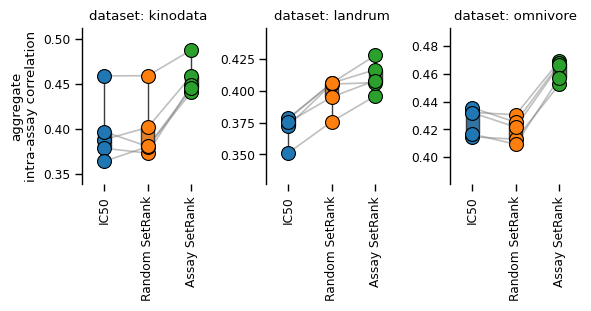

In [21]:
sns.set_context("paper")
datasets = ["kinodata", "landrum", "omnivore"]#, "solubility", "clearance", "cell_line"]
d = d[d["dataset"].isin(datasets)]
methods = ["ic50", "allsets", "sets"]
d = d[d["method"].isin(methods)]
width = 2
n_ds = d["dataset"].nunique()
fig, axes = plt.subplots(1, n_ds, figsize=(width * n_ds, 3.2), sharey=False)
colors = dict(zip(methods, sns.color_palette()))

if d["dataset"].nunique() == 1:
    axes = [axes]

identity = lambda x: x
transform = inv_transform = identity
# transform, inv_transform = np.atanh, np.tanh

datasets = [ds for ds in datasets if ds in d["dataset"].unique()]
for ax, dataset in zip(axes, datasets):
    df = d[d["dataset"] == dataset]
    for fold, group in df.groupby("fold"):
        group = group.set_index("method").reindex(methods).dropna().reset_index()
        ax.plot(
            group["method"],
            transform(group["corr"]),
            linestyle="-",
            color="gray",
            alpha=0.5,
            zorder=0,
        )

    for method in methods:
        subset = df[(df["method"] == method) & (df["status"] == "Finished")]
        if len(subset) > 0:
            ax.scatter(
                subset["method"],
                transform(subset["corr"]),
                s=100,
                label=method,
                color=colors[method],
                edgecolors="black",
                marker="o",
            )
    sns.boxplot(
        df,
        x="method",
        y=transform(df["corr"]),
        hue="method",
        palette=colors,
        ax=ax,
        zorder=0,
        width=0.3,
        whis=10000,
    )

    ms = [str(Method.from_string(m)) for m in methods if m in df["method"].unique()]

    ax.set_title(f"dataset: {dataset}")
    ax.set_ylim(transform(df["corr"].min() * 0.93), transform(df["corr"].max() * 1.05))
    yt = ax.get_yticks()
    ax.set_ylabel(None)
    ax.set_xlabel(None)
    ax.set_xticks(range(len(ms)))
    ax.set_xticklabels(ms, rotation=90)
    ax.set_xlim(-0.5, len(ms) - 0.5)
    sns.despine(ax=ax, left=False, bottom=True)

    # ax.set_yticks([])
    # ax.set_yticks(yt, labels=[f"{x:.2f} {np.tanh(x):.2f}" for x in yt])

axes[0].set_ylabel("aggregate\nintra-assay correlation")
plt.tight_layout()
plt.savefig("results.svg")

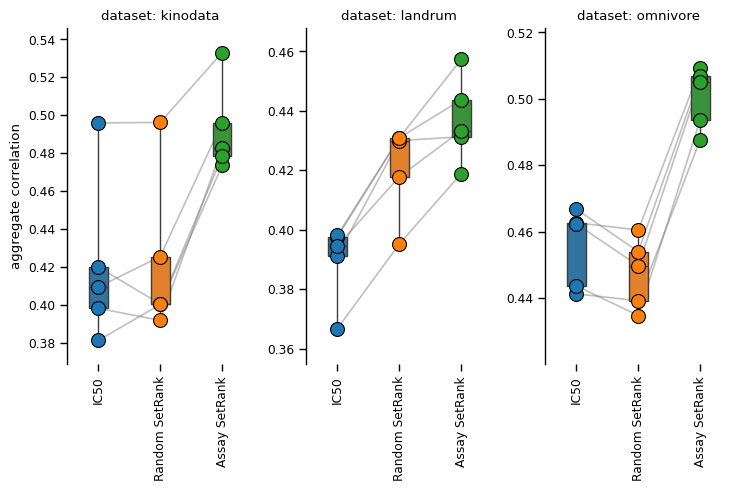

In [36]:
plot_results(
    d[d["dataset"].isin(["kinodata", "landrum", "omnivore"])],
    ["ic50", "allsets", "sets"],
    width=2.5,
)
plt.savefig("img/chembl_performances.pdf")

In [37]:
# Pivot the data to get methods as columns
pivoted = d[d["dataset"].isin(["kinodata", "landrum", "omnivore"])].pivot_table(
    index=['dataset', 'fold'], 
    columns='method', 
    values='corr'
).reset_index()

# Generate the LaTeX table
tabl = pivoted[['dataset', 'fold', 'ic50', 'allsets', 'sets']].to_latex(
    index=False,
    sparsify=True,
    multirow=True,
    float_format="%.4f",
)
print(tabl)

\begin{tabular}{lrrrr}
\toprule
dataset & fold & ic50 & allsets & sets \\
\midrule
kinodata & 0 & 0.3879 & 0.4015 & 0.4590 \\
kinodata & 1 & 0.4589 & 0.4591 & 0.4877 \\
kinodata & 2 & 0.3783 & 0.3729 & 0.4484 \\
kinodata & 3 & 0.3637 & 0.3801 & 0.4410 \\
kinodata & 4 & 0.3968 & 0.3803 & 0.4449 \\
landrum & 0 & 0.3511 & 0.3758 & 0.3960 \\
landrum & 1 & 0.3778 & 0.4061 & 0.4279 \\
landrum & 2 & 0.3724 & 0.4053 & 0.4064 \\
landrum & 3 & 0.3783 & 0.4061 & 0.4167 \\
landrum & 4 & 0.3752 & 0.3951 & 0.4081 \\
omnivore & 0 & 0.4323 & 0.4305 & 0.4693 \\
omnivore & 1 & 0.4147 & 0.4130 & 0.4524 \\
omnivore & 2 & 0.4356 & 0.4252 & 0.4675 \\
omnivore & 3 & 0.4320 & 0.4217 & 0.4662 \\
omnivore & 4 & 0.4167 & 0.4093 & 0.4572 \\
\bottomrule
\end{tabular}



In [11]:
from scipy.stats import ttest_rel

In [12]:
import itertools as itt

In [13]:
methods = ['ic50', 'allsets', 'sets']
for dataset, data in d.groupby('dataset'):
    print(dataset)
    for m1, m2 in itt.combinations(methods, 2):
        d1 = np.atanh(data[data['method'] == m1].sort_values('fold')['corr'].values)
        d2 = np.atanh(data[data['method'] == m2].sort_values('fold')['corr'].values)
        print(f" {m1} < {m2}: p={ttest_rel(d1, d2, alternative='less').pvalue * 3:.4f}")

cell_line
 ic50 < allsets: p=2.9993
 ic50 < sets: p=0.0000
 allsets < sets: p=0.0000
clearance
 ic50 < allsets: p=2.9634
 ic50 < sets: p=0.0010
 allsets < sets: p=0.0000
kinodata
 ic50 < allsets: p=1.1998
 ic50 < sets: p=0.0035
 allsets < sets: p=0.0022
landrum
 ic50 < allsets: p=0.0004
 ic50 < sets: p=0.0004
 allsets < sets: p=0.0344
omnivore
 ic50 < allsets: p=2.9525
 ic50 < sets: p=0.0000
 allsets < sets: p=0.0000
solubility
 ic50 < allsets: p=0.1484
 ic50 < sets: p=0.0003
 allsets < sets: p=0.0017


In [35]:
import numpy as np
import itertools as itt
from scipy.stats import ttest_rel, wilcoxon

def cohens_d(x, y):
    """Paired Cohen's d"""
    diff = x - y
    return diff.mean() / diff.std(ddof=1)

methods = ['ic50', 'allsets', 'sets']

for dataset, data in d.groupby('dataset'):
    print(f"\nDataset: {dataset}")
    for m1, m2 in itt.combinations(methods, 2):
        # Extract and transform correlations
        d1 = np.atanh(data[data['method'] == m1].sort_values('fold')['corr'].values)
        d2 = np.atanh(data[data['method'] == m2].sort_values('fold')['corr'].values)

        # Paired t-test
        ttest_p = ttest_rel(d1, d2, alternative='less').pvalue

        # Wilcoxon test (signed-rank, alternative='less')
        try:
            wilcoxon_p = wilcoxon(d1, d2, alternative='less').pvalue
        except ValueError:
            wilcoxon_p = np.nan  # Happens if all differences are zero

        # Cohen's d
        cd = cohens_d(d1, d2)

        # Print results with Bonferroni correction (3 comparisons)
        print(f" {m1} < {m2}: "
              f"\n  t-test p={ttest_p * 3:.4f}, "
              f"\n  wilcoxon p={wilcoxon_p * 3:.4f}, "
              f"\n  Cohen's d={cd:.3f}")


Dataset: cell_line
 ic50 < allsets: 
  t-test p=2.9993, 
  wilcoxon p=3.0000, 
  Cohen's d=4.626
 ic50 < sets: 
  t-test p=0.0000, 
  wilcoxon p=0.0938, 
  Cohen's d=-29.867
 allsets < sets: 
  t-test p=0.0000, 
  wilcoxon p=0.0938, 
  Cohen's d=-10.572

Dataset: clearance
 ic50 < allsets: 
  t-test p=2.9634, 
  wilcoxon p=3.0000, 
  Cohen's d=1.576
 ic50 < sets: 
  t-test p=0.0010, 
  wilcoxon p=0.0938, 
  Cohen's d=-4.311
 allsets < sets: 
  t-test p=0.0000, 
  wilcoxon p=0.0938, 
  Cohen's d=-9.805

Dataset: kinodata
 ic50 < allsets: 
  t-test p=1.1998, 
  wilcoxon p=1.5000, 
  Cohen's d=-0.121
 ic50 < sets: 
  t-test p=0.0035, 
  wilcoxon p=0.0938, 
  Cohen's d=-3.072
 allsets < sets: 
  t-test p=0.0022, 
  wilcoxon p=0.0938, 
  Cohen's d=-3.486

Dataset: landrum
 ic50 < allsets: 
  t-test p=0.0004, 
  wilcoxon p=0.0938, 
  Cohen's d=-5.427
 ic50 < sets: 
  t-test p=0.0004, 
  wilcoxon p=0.0938, 
  Cohen's d=-5.401
 allsets < sets: 
  t-test p=0.0344, 
  wilcoxon p=0.0938, 
  Cohe

In [17]:
import numpy as np
import itertools as itt
from scipy.stats import ttest_rel, wilcoxon
from statsmodels.stats.multitest import multipletests

def cohens_d(x, y):
    """Paired Cohen's d"""
    diff = x - y
    return diff.mean() / diff.std(ddof=1)

methods = ['ic50', 'allsets', 'sets']

for dataset, data in d.groupby('dataset'):
    print(f"\nDataset: {dataset}")

    comparisons = list(itt.combinations(methods, 2))
    results = []

    # Step 1: Run all tests and store uncorrected p-values
    for m1, m2 in comparisons:
        d1 = np.atanh(data[data['method'] == m1].sort_values('fold')['corr'].values)
        d2 = np.atanh(data[data['method'] == m2].sort_values('fold')['corr'].values)

        # Paired t-test
        ttest_p = ttest_rel(d1, d2, alternative='less').pvalue

        # Wilcoxon test
        try:
            wilcoxon_p = wilcoxon(d1, d2, alternative='less').pvalue
        except ValueError:
            wilcoxon_p = np.nan

        # Effect size
        d_val = cohens_d(d1, d2)

        results.append({
            'm1': m1,
            'm2': m2,
            'ttest_p': ttest_p,
            'wilcoxon_p': wilcoxon_p,
            'cohens_d': d_val
        })

    # Step 2: Apply BH correction
    ttest_pvals = [r['ttest_p'] for r in results]
    wilcoxon_pvals = [r['wilcoxon_p'] if not np.isnan(r['wilcoxon_p']) else 1.0 for r in results]  # fill nan with 1.0

    _, ttest_pvals_corrected, _, _ = multipletests(ttest_pvals, method='fdr_bh')
    _, wilcoxon_pvals_corrected, _, _ = multipletests(wilcoxon_pvals, metAAAIhod='fdr_bh')

    # Step 3: Print results
    for i, r in enumerate(results):
        print(f" {r['m1']} < {r['m2']}: "
              f"t-test (FDR) p={ttest_pvals_corrected[i]:.4f}, "
              f"wilcoxon (FDR) p={wilcoxon_pvals_corrected[i]:.4f}, "
              f"Cohen's d={r['cohens_d']:.3f}")


Dataset: kinodata
 ic50 < allsets: t-test (FDR) p=0.2112, wilcoxon (FDR) p=0.3125, Cohen's d=-0.399
 ic50 < sets: t-test (FDR) p=0.0009, wilcoxon (FDR) p=0.0469, Cohen's d=-4.398
 allsets < sets: t-test (FDR) p=0.0033, wilcoxon (FDR) p=0.0469, Cohen's d=-2.595

Dataset: landrum
 ic50 < allsets: t-test (FDR) p=0.0010, wilcoxon (FDR) p=0.0312, Cohen's d=-3.582
 ic50 < sets: t-test (FDR) p=0.0010, wilcoxon (FDR) p=0.0312, Cohen's d=-4.041
 allsets < sets: t-test (FDR) p=0.0061, wilcoxon (FDR) p=0.0312, Cohen's d=-1.940

Dataset: omnivore
 ic50 < allsets: t-test (FDR) p=0.8312, wilcoxon (FDR) p=0.9062, Cohen's d=0.487
 ic50 < sets: t-test (FDR) p=0.0000, wilcoxon (FDR) p=0.0469, Cohen's d=-11.261
 allsets < sets: t-test (FDR) p=0.0001, wilcoxon (FDR) p=0.0469, Cohen's d=-5.853


In [14]:
' & '.join(f"{float(s.strip())**2:.4f}" if s.strip() != 'NA' else 'NA' for s in """
            0.4178 & NA & 0.6326
            & 0.4978 & NA & 0.6327
            & NA & 0.6007
            """.split('&'))

'0.1746 & NA & 0.4002 & 0.2478 & NA & 0.4003 & NA & 0.3608'

In [4]:
inp

[0.12124324,
 0.11675889,
 0.13920360999999998,
 0.27040000000000003,
 0.26822041,
 0.31877316,
 0.28419561000000004,
 0.31550689]